In [1]:
import os
from types import SimpleNamespace
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim, amp
from torch.optim import lr_scheduler
import torchvision.utils as vutils

In [2]:
from utils.logger import get_logger, log_config
from utils.image_quality_assessment import PSNR, SSIM
from utils.dataset import get_dataloader
from models.select_model import get_model
from utils.train_model import train, validate
import utils.visualizations as viz
from utils.preprocessing import richardson_lucy_deconv, wiener_filter, apply_bm3d, apply_nlm

In [3]:
df = pd.read_csv('data/caco2/caco2/caco2_patches.csv')


In [4]:
train_set = [1, 2,3,4,5,6,8,12,13,15,16,17,18,21,22]
val_set = [7,11,19]
test_set = [9,10,14,20]

In [5]:
from scipy.ndimage import gaussian_filter

# Create a 2D Gaussian PSF


def gaussian_psf(size=13, sigma=2):
    psf = np.zeros((size, size))
    psf[size // 2, size // 2] = 1
    psf = gaussian_filter(psf, sigma=sigma)
    psf /= psf.sum()  # normalize
    return psf

In [6]:
psf = gaussian_psf(size=7, sigma=0.69)
wiener_rl = [
    lambda x: wiener_filter(x, psf, noise=0.01),
    lambda x: richardson_lucy_deconv(x, psf=psf, num_iter=50)
]

In [7]:
bm3d = [lambda x: apply_bm3d(x, sigma=0.01)]

# nlm= [lambda x: nlm(x, h=0.1)]

bm3d_nlm = [
    lambda x: apply_bm3d(x, sigma=0.05),
    lambda x: apply_nlm(x, h=0.1)
]

In [8]:
wiener_rl_bm3d = bm3d + wiener_rl

In [60]:
srcnn_config = SimpleNamespace(
    exp_name="srcnn_base_caco2_x4_d92_1e-4",
    dataset="caco2",
    data_dir="data/caco2/caco2",
    # preprocess=[lambda x: wiener_filter(x, psf, noise=0.01)],
    # preprocess = [lambda x: apply_bm3d(x, sigma=0.01)],
    # preprocess=[lambda x: apply_nlm(x, h=0.1)],
    # preprocess=[lambda x: richardson_lucy_deconv(x, psf, num_iter=50)],
    preprocess=None,
    upscale_factor=4,
    only_test_y_channel=False,
    in_chans=1,
    psf_size=9,
    rl_iters=5,
    model_name="srcnn",
    arch='base',
    epochs=20,
    lr=0.0001,
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    batch_size=4,
    lr_scheduler_step_size=4,  # epochs // 5,
    lr_scheduler_gamma=0.5,
)

In [45]:

srgan_config = SimpleNamespace(
    exp_name="srgan_caco2",
    log_dir="logs",
    epochs=10,
    lr=1e-4,
    batch_size=16,
    gan_weight=1e-3  # how much to scale the adversarial loss
)

In [70]:
edsr_config = SimpleNamespace(
    exp_name="edsr_Prl_base_caco2_x4_d92_e20_lr1e4",
    model_name="edsr",
    arch='base',
    dataset="caco2",
    data_dir="data/caco2/caco2",
    # preprocess=None,
    # preprocess=[lambda x: wiener_filter(x, psf, noise=0.01)],
    preprocess=[lambda x: richardson_lucy_deconv(x, psf, num_iter=50)],
    upscale_factor=4,
    in_chans=1,
    rl_iters=12,
    device=torch.device("cuda", 0),
    log_dir="logs",
    epochs=20,
    lr=0.0001,
    betas = (0.9, 0.999),
    batch_size=4,
    num_workers = 4,
    lr_scheduler_step_size = 4, #epochs // 5,
    lr_scheduler_gamma = 0.5,
    only_test_y_channel = False
)

In [47]:
rcan_config = SimpleNamespace(
    exp_name="rcan_Pdec_Den_base_caco2_x4_d92_lr1e04",
    model_name="rcan",
    model_arch="rcan_x4",
    dataset="caco2",
    data_dir="data/caco2/caco2",
    # preprocess=wiener_rl_bm3d,
    preprocess=[lambda x: wiener_filter(x, psf, noise=0.01)],
    # preprocess=[lambda x: richardson_lucy_deconv(x, psf, num_iter=50)],
    upscale_factor=4,
    in_chans=1,
    out_chans=1,
    device=torch.device("cuda", 0),
    log_dir="logs",
    epochs=20,
    lr=0.0001,
    betas=(0.9, 0.999),
    batch_size=2,
    num_workers=4,
    gan_weight=1e-3,
    lr_scheduler_step_size=2,  # epochs // 5,
    lr_scheduler_gamma=0.5,
    only_test_y_channel=False
)

In [71]:
config = edsr_config

base_path = os.path.join("logs", config.exp_name)
os.makedirs(base_path, exist_ok=True)
logger = get_logger(config)

In [72]:
train_loader = get_dataloader(
    dataset_type='caco2',
    dataframe=df,
    base_dir=config.data_dir,
    tiles_id=train_set[:4],
    scale=config.upscale_factor,
    batch_size=config.batch_size,
    preprocessors=config.preprocess,
    shuffle=False,
)
val_loader = get_dataloader(
    dataset_type=config.dataset,
    dataframe=df,
    base_dir=config.data_dir,
    tiles_id=val_set[:2],
    scale=config.upscale_factor,
    batch_size=config.batch_size, shuffle=False,
    preprocessors=config.preprocess
)

In [73]:
for batch in train_loader:
    lr = batch['lr']
    hr = batch['hr']
    print(f"Train Loader:: LR shape: {lr.shape}, HR shape: {hr.shape}")
    break

for batch in val_loader:
    lr = batch['lr']
    hr = batch['hr']
    print(f"Val Loader:: LR shape: {lr.shape}, HR shape: {hr.shape}")
    break

# print(f"Train samples: {len(train_loader.dataset)}")
print(f"Val samples: {len(val_loader.dataset)}")

Train Loader:: LR shape: torch.Size([4, 1, 128, 128]), HR shape: torch.Size([4, 1, 512, 512])
Val Loader:: LR shape: torch.Size([4, 1, 128, 128]), HR shape: torch.Size([4, 1, 512, 512])
Val samples: 716


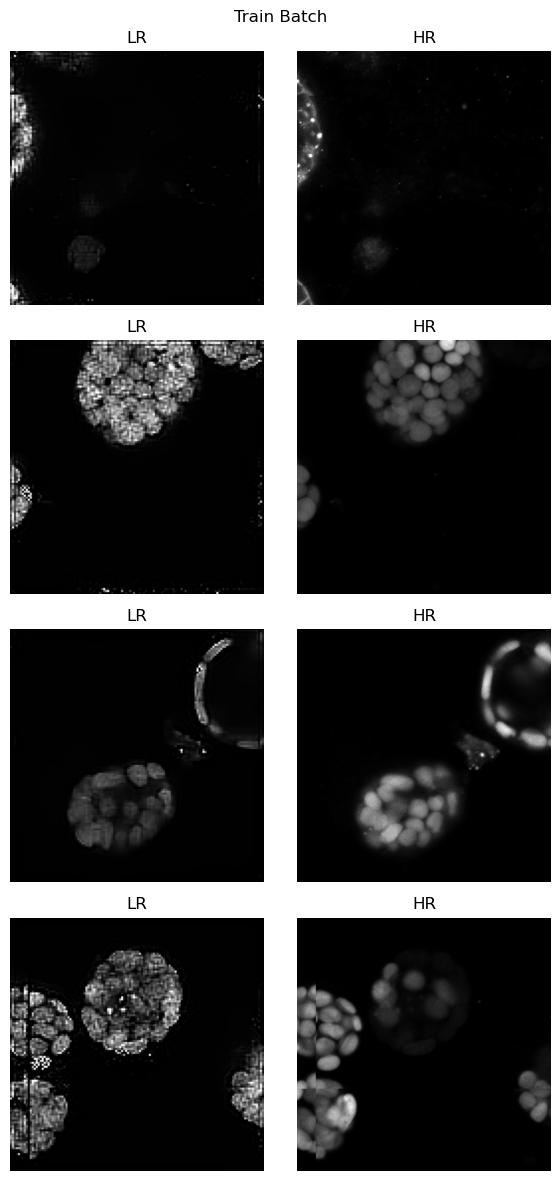

In [51]:
viz.visualize_batch(train_loader, n=4, title="Train Batch")

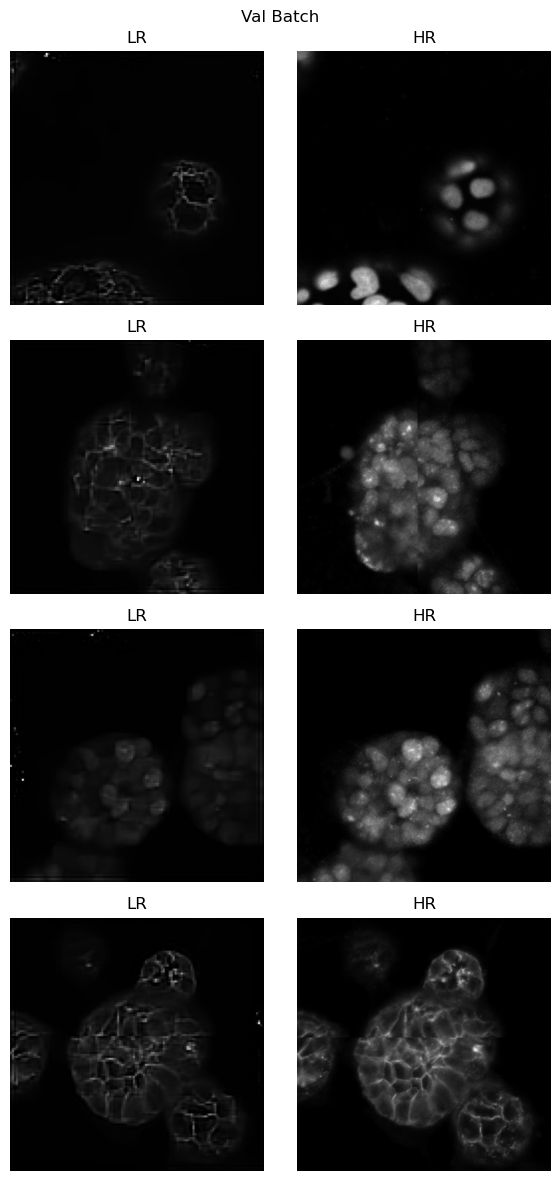

In [52]:
viz.visualize_batch(val_loader, n=4, title="Val Batch")

In [74]:
start_epoch = 0
best_psnr = 0.0
best_ssim = 0.0
train_losses,train_psnrs, val_psnrs, val_ssims = [], [], [], []

In [75]:
# Build model
model = get_model("edsr", config)
print(f"{config.model_name} model built successfully.")
# log_config(logger, config)

namespace(exp_name='edsr_Prl_base_caco2_x4_d92_e20_lr1e4', model_name='edsr', arch='base', dataset='caco2', data_dir='data/caco2/caco2', preprocess=[<function <lambda> at 0x7e32dc07ed40>], upscale_factor=4, in_chans=1, rl_iters=12, device=device(type='cuda', index=0), log_dir='logs', epochs=20, lr=0.0001, betas=(0.9, 0.999), batch_size=4, num_workers=4, lr_scheduler_step_size=4, lr_scheduler_gamma=0.5, only_test_y_channel=False)
edsr model built successfully.


In [76]:
criterion = nn.L1Loss().to(config.device)
# criterion = nn.L1Loss()
print("Define all loss functions successfully.")

optimizer = optim.Adam(model.parameters(), config.lr)
print("Define all optimizer functions successfully.")

scheduler = lr_scheduler.StepLR(
    optimizer, config.lr_scheduler_step_size, config.lr_scheduler_gamma)

print("Define all optimizer scheduler successfully.")

Define all loss functions successfully.
Define all optimizer functions successfully.
Define all optimizer scheduler successfully.


In [77]:
# Initialize the gradient scaler
scaler = amp.GradScaler()

In [78]:
 # Create an IQA evaluation model
psnr_model = PSNR(config.upscale_factor,
                  config.only_test_y_channel)
psnr_model = psnr_model.to(device=config.device,
                           memory_format=torch.channels_last, non_blocking=True)

ssim_model = SSIM(config.upscale_factor,
                  config.only_test_y_channel)
ssim_model = ssim_model.to(device=config.device,
                           memory_format=torch.channels_last, non_blocking=True)

In [233]:
# no_improve_counter = 0
# # Directory to save the model
# # base_path = os.path.join(config.log_dir, config.exp_name)
# # os.makedirs(base_path, exist_ok=True)
# # logger = get_logger(config)

# for epoch in range(start_epoch, config.epochs):
#     train_loss, train_psnr = train(model, train_loader, optimizer, criterion, psnr_model, scaler, epoch, logger, 'post')
#     train_losses.append(train_loss)
#     train_psnrs.append(train_psnr)


#     psnr, ssim = validate(model, val_loader, psnr_model, ssim_model, logger, 'post')
#     val_psnrs.append(psnr)
#     val_ssims.append(ssim)

#     # Save the model
#     is_best = psnr > best_psnr and ssim > best_ssim
#     if is_best:
#         best_psnr = max(psnr, best_psnr)
#         best_ssim = max(ssim, best_ssim)
#         no_improve_counter = 0
#         best_model_path = os.path.join(base_path, f"best_model_epoch_{epoch + 1}.pth")
#         torch.save(model.state_dict(), best_model_path)
#         print(
#             f"Best model saved at {best_model_path} epoch {epoch + 1} | PSNR: {best_psnr}, SSIM: {best_ssim}")
#     else:
#         no_improve_counter += 1
#         print(
#             f"Model at epoch {epoch + 1} did not improve. PSNR: {psnr}, SSIM: {ssim}")
#     # Save the final model
#     if (epoch + 1) == config.epochs:
#         final_model_path = os.path.join(base_path, f"final_model_epoch_{epoch + 1}.pth")
#         torch.save(model.state_dict(), final_model_path)
#         print(
#             f"Final model saved at {final_model_path} epoch {epoch + 1} with PSNR: {best_psnr}, SSIM: {best_ssim}")
#     # Update the learning rate
#     # scheduler.step()
#     # print(f"Learning rate updated to: {scheduler.get_last_lr()[0]}")
#     # Log the results
#     logger.info(f"Best PSNR: {best_psnr:.4f}, Best SSIM: {best_ssim:.4f}")

#     # Early stopping check
#     if no_improve_counter >= 5:
#         print(
#             f"Early stopping triggered. No improvement in 5 epochs.")
#         break

# df = pd.DataFrame({
#     'epoch': list(range(start_epoch + 1, start_epoch + 1 + len(train_losses))),
#     'train_loss': train_losses,
#     'train_psnr': train_psnrs,
#     'val_psnr': val_psnrs,
#     'val_ssim': val_ssims,
# })
# df.to_csv(os.path.join(base_path, "training_log.csv"), index=False)

In [234]:
# viz.plot_psnr(
#     psnr_dict={
#         'Train PSNR': train_psnrs,
#         'Val PSNR': val_psnrs,
#     },
#     save_path=f'logs/{config.exp_name}/psnr_plot_.png',
#     title='PSNR over Epochs'
# )

In [80]:
viz.visualize_model_res(
    model=model,
    preload=True,
    best_model_epoch=5,
    config=config,
    val_dataset=val_loader.dataset,
    device=config.device,
    psnr_model=psnr_model,
    ssim_model=ssim_model,
    model_type='post',
    save_dir=f'results/{config.exp_name}',
    suffix='_1',
    num_samples=5,
    fixed_indices=[5, 23, 69, 169, 200],
)

Loading model from logs/edsr_Prl_base_caco2_x4_d92_e20_lr1e4/best_model_epoch_5.pth
Saved: results/edsr_Prl_base_caco2_x4_d92_e20_lr1e4/sample_5_1_viz.png
Saved: results/edsr_Prl_base_caco2_x4_d92_e20_lr1e4/sample_23_1_viz.png
Saved: results/edsr_Prl_base_caco2_x4_d92_e20_lr1e4/sample_69_1_viz.png
Saved: results/edsr_Prl_base_caco2_x4_d92_e20_lr1e4/sample_169_1_viz.png
Saved: results/edsr_Prl_base_caco2_x4_d92_e20_lr1e4/sample_200_1_viz.png


In [ ]:
# from torchvision.transforms.functional import to_pil_image
# with torch.no_grad():
#     for idx, batch in enumerate(val_loader):
#         lr = batch['lr'].to(device=config.device)
#         hr = batch['hr'].to(device=config.device)
#         lr = nn.functional.interpolate(
#                     lr, size=(hr.shape[2], hr.shape[3]), mode='bicubic', align_corners=False)
#         sr = model(lr)

#         # Detach & convert to numpy
#         lr_img = lr[0].cpu().clamp(0, 1)
#         sr_img = sr[0].cpu().clamp(0, 1)
#         hr_img = hr[0].cpu().clamp(0, 1)

#         print(f"LR shape: {lr_img.shape}, SR shape: {sr_img.shape}, HR shape: {hr_img.shape}")

#         psnr_val = psnr_model(sr, hr).mean().item()
#         ssim_val = ssim_model(sr, hr).mean().item()

#         print(f"PSNR: {psnr_val:.4f}, SSIM: {ssim_val:.4f}")
#         # Plot
#         fig, axs = plt.subplots(1, 3, figsize=(12, 4))
#         axs[0].imshow(to_pil_image(lr_img), cmap='gray')
#         axs[0].set_title('Low-Res Input')
#         axs[1].imshow(to_pil_image(sr_img), cmap='gray')
#         axs[1].set_title('Super-Res Output')
#         axs[2].imshow(to_pil_image(hr_img), cmap='gray')
#         axs[2].set_title('High-Res Ground Truth')
#         for ax in axs:
#             ax.axis('off')
#         plt.tight_layout()
#         plt.show()
#         if idx + 1 >= 2:
#             break